In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score, accuracy_score

In [4]:
# Total detectors 786, we are having 725 in triplets and 25 duets
df_triplets = pd.read_csv('./result_csv/triplets.csv')
df_duets = pd.read_csv('./result_csv/duets.csv')

dfv = pd.read_csv("./data/flow_10.23-03.24.csv")
dfl = pd.read_csv("./data/lane_10.23-03.24.csv")
dfv.loc[:,'timestamp'] = pd.to_datetime(dfv['timestamp'], errors='coerce')
dfv.set_index("timestamp",inplace=True)

c:\Program Files\Python311\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


In [5]:
df = pd.read_csv('./result_csv/data_matrix.csv')
df.loc[:,'timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df.set_index("timestamp",inplace=True)
df

c:\Program Files\Python311\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


,AID01101,AID01102,AID01103,AID01104,AID01105,AID01106,AID01107,AID01108,AID01109,AID01110,...,TDSTTR10003,TDSTYR10001,TDSTYR10002,TDSTYR10003,TDSYSR10001,TDSYSR10002,TDSYSR10003,TDSYSR20001,TDSYSR20002,TDSYSR20003
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-10-01,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,...,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2023-10-02,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2023-10-03,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,...,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,-1.0
2023-10-04,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,...,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,-1.0
2023-10-05,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,...,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-27,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,...,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2024-03-28,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,...,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2024-03-29,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


In [10]:
# # Here is the rule to make correlation matrix for all those detectors present in triplet df
# # nan value represent the same nan values in data matrix (>5% null)

# df_new = df.copy()
# for idx in df.index:
#     for i in df.columns:

#         if pd.isna(df.loc[idx, i]):
#             df_new.loc[idx,i]=np.nan
#             continue

#         corr = np.nan
#         row_id_0 = df_triplets.index[df_triplets['0'].isin([i])]
#         row_id_1 = df_triplets.index[df_triplets['1'].isin([i])]
#         row_id_2 = df_triplets.index[df_triplets['2'].isin([i])]
#         if(not(row_id_1.empty)):
#             det = df_triplets.loc[row_id_1].values.flatten().tolist()
#             t1 = det[0]+'_total_flow' in dfv.columns
#             t3 = det[2]+'_total_flow' in dfv.columns

#             if(t1 and t3):
#                 det1 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[0]+'_total_flow']
#                 det2 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[1]+'_total_flow']
#                 det3 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[2]+'_total_flow']

#                 corr = (det2.corr(det1) + det2.corr(det3))/2
#             elif(t1 and not(t3)):
#                 det1 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[0]+'_total_flow']
#                 det2 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[1]+'_total_flow']

#                 corr = det2.corr(det1)
#             elif(t3 and not(t1)):
#                 det2 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[1]+'_total_flow']
#                 det3 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[2]+'_total_flow']

#                 corr = det2.corr(det3)                    

#         elif(not(row_id_0.empty)):
#             det = df_triplets.loc[row_id_0].values.flatten().tolist()
#             det1 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[0]+'_total_flow']
#             det2 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[1]+'_total_flow']

#             corr = det2.corr(det1)

#         elif(not(row_id_2.empty)):
#             det = df_triplets.loc[row_id_2].values.flatten().tolist()
#             det2 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[1]+'_total_flow']
#             det3 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[2]+'_total_flow']

#             corr = det2.corr(det3)

#         df_new.loc[idx,i] = corr

In [11]:
# df_new.to_csv('./result_csv/corr_matrix_classification.csv')

In [12]:
df_new = pd.read_csv('./result_csv/corr_matrix_classification.csv')
df_new.loc[:,'timestamp'] = pd.to_datetime(df_new['timestamp'], errors='coerce')
df_new.set_index("timestamp",inplace=True)
print(df_new.to_string())

c:\Program Files\Python311\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


            AID01101  AID01102  AID01103  AID01104  AID01105  AID01106  AID01107  AID01108  AID01109  AID01110  AID01111  AID01112  AID01113  AID01114  AID01115  AID01116  AID01117  AID01118  AID01119  AID01120  AID01121  AID01122  AID01123  AID01124  AID01125  AID01126  AID01127  AID01128  AID01129  AID01130  AID01131  AID01132  AID01133  AID01134  AID01135  AID01136  AID01201  AID01202  AID01203  AID01204  AID01205  AID01206  AID01207  AID01208  AID01209  AID01210  AID01211  AID01212  AID01213  AID01214  AID01215  AID01216  AID01217  AID01218  AID01219  AID01220  AID01221  AID01222  AID01223  AID02104  AID02105  AID02106  AID02107  AID02108  AID02109  AID02110  AID02111  AID02112  AID02113  AID02114  AID02115  AID02116  AID02117  AID02118  AID02119  AID02120  AID02121  AID02122  AID02123  AID02124  AID02125  AID02126  AID02127  AID02201  AID02202  AID02203  AID02204  AID02205  AID02206  AID02207  AID02208  AID02209  AID02210  AID02211  AID02212  AID02213  AID02214  AID02215  AID03102

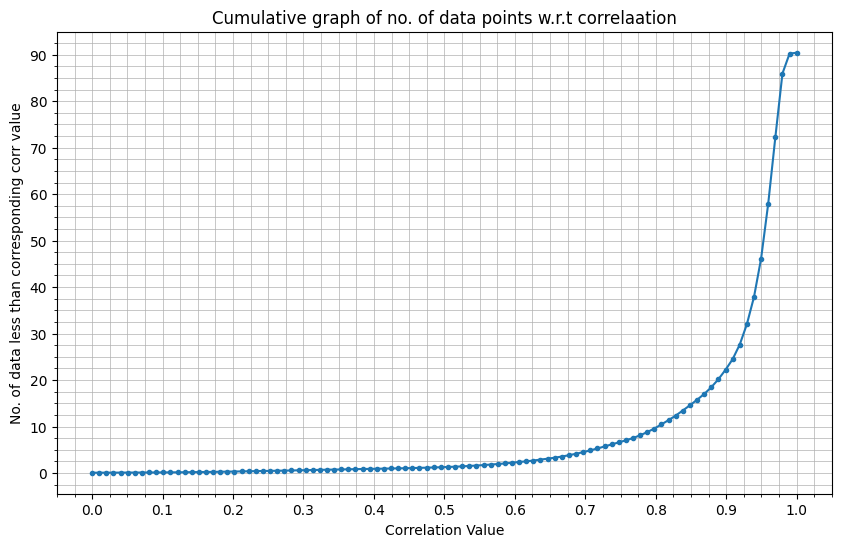

In [13]:
x_min, x_max, intervals = 0, 1, 100
x_values = np.linspace(x_min, x_max, intervals)

# Flatten the DataFrame into a single series
values = df_new.values.flatten()

# Calculate the number of values less than each x value
y_values = [100*(values < x).sum()/len(values) for x in x_values]

# Plot the graph
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, marker='.', linestyle='-')
plt.xlabel('Correlation Value')
plt.ylabel('No. of data less than corresponding corr value')
plt.title('Cumulative graph of no. of data points w.r.t correlaation')

plt.grid(which='both', linestyle='-', linewidth='0.5')
plt.minorticks_on()

# Customize the major and minor grid lines for x-axis
plt.gca().xaxis.set_major_locator(plt.MultipleLocator(0.1))
plt.gca().xaxis.set_minor_locator(plt.MultipleLocator(0.025))

# Customize the major and minor grid lines for y-axis
plt.gca().yaxis.set_major_locator(plt.MultipleLocator(10))
plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(2.5))

plt.grid(True)
plt.show()

In [14]:
print('Values less than 0.7: ',(values<=0.7).sum())
print('Values more than 0.9: ',(values>=0.9).sum())

Values less than 0.7:  5918
Values more than 0.9:  87260


In [18]:
# Target matrix is the labelling required for supervised training
df_target = df_new.copy()


df_target[df_new > 0.9] = 1      # 1 is label for good data
df_target[(df_new <= 0.9) & (df_new >= 0.7)] = -1    # -1 is label for unsure data which we dont train
df_target[df_new < 0.7] = 0  # 0 is label for bad data

# Preserve NaN values
df_target = df_target.where(~df_new.isna(), np.nan)

print(df_target.to_string())

            AID01101  AID01102  AID01103  AID01104  AID01105  AID01106  AID01107  AID01108  AID01109  AID01110  AID01111  AID01112  AID01113  AID01114  AID01115  AID01116  AID01117  AID01118  AID01119  AID01120  AID01121  AID01122  AID01123  AID01124  AID01125  AID01126  AID01127  AID01128  AID01129  AID01130  AID01131  AID01132  AID01133  AID01134  AID01135  AID01136  AID01201  AID01202  AID01203  AID01204  AID01205  AID01206  AID01207  AID01208  AID01209  AID01210  AID01211  AID01212  AID01213  AID01214  AID01215  AID01216  AID01217  AID01218  AID01219  AID01220  AID01221  AID01222  AID01223  AID02104  AID02105  AID02106  AID02107  AID02108  AID02109  AID02110  AID02111  AID02112  AID02113  AID02114  AID02115  AID02116  AID02117  AID02118  AID02119  AID02120  AID02121  AID02122  AID02123  AID02124  AID02125  AID02126  AID02127  AID02201  AID02202  AID02203  AID02204  AID02205  AID02206  AID02207  AID02208  AID02209  AID02210  AID02211  AID02212  AID02213  AID02214  AID02215  AID03102

In [19]:
count_zeros = (df_target == 0).sum()
print(count_zeros.to_string())

AID01101            1
AID01102            0
AID01103            0
AID01104            0
AID01105            0
AID01106            2
AID01107            2
AID01108            0
AID01109            0
AID01110            0
AID01111            0
AID01112            0
AID01113            0
AID01114            0
AID01115            6
AID01116            0
AID01117            8
AID01118            0
AID01119            0
AID01120            0
AID01121            1
AID01122            2
AID01123            3
AID01124            0
AID01125            0
AID01126            0
AID01127            0
AID01128            0
AID01129           23
AID01130           22
AID01131           25
AID01132            0
AID01133            0
AID01134            0
AID01135            0
AID01136            0
AID01201            0
AID01202            0
AID01203            0
AID01204            0
AID01205            0
AID01206            0
AID01207            0
AID01208            0
AID01209            0
AID01210  

In [20]:
# # Incase we want subset of the dataset
# df_target_ = df_target.loc[:, count_zeros >= 5]
# df_target_ = df_target_.loc[:, count_zeros < 100]
df_target_ = df_target.copy()

In [22]:
detector_dict = {}
# This dictionary contains the position of the detector in the triplet dataset for a particular detector
# The first value is the index of row, and 2nd value is column name (index of position of the detector in triplet)

for det in df_target_.columns:
    val1= np.nan
    val2=np.nan

    if det in df_triplets['1'].values:
        val1 = int(np.where( df_triplets['1'].values == det)[0])
        val2 = 1
    elif det in df_triplets['0'].values:
        val1 = int(np.where( df_triplets['0'].values == det)[0])
        val2 = 0
    elif det in df_triplets['2'].values:
        val1 = int(np.where( df_triplets['2'].values == det)[0])
        val2 = 2
    
    detector_dict.update({det : [val1,val2]})
len(detector_dict)

C:\Users\Nahush\AppData\Local\Temp\ipykernel_11508\3849528119.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  val1 = int(np.where( df_triplets['0'].values == det)[0])
C:\Users\Nahush\AppData\Local\Temp\ipykernel_11508\3849528119.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  val1 = int(np.where( df_triplets['1'].values == det)[0])
C:\Users\Nahush\AppData\Local\Temp\ipykernel_11508\3849528119.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  val1 = int

701

In [24]:
# We drop those detectors in the triplet dataset for which we dont have data 
drop_list = []
for detector in df_target_.columns:
    triplet_idx = detector_dict[detector][0]
    det_arr = list(df_triplets.loc[triplet_idx])
    for det in det_arr:
        if(det+'_total_flow' not in dfv.columns):
            drop_list.append(detector)
print(drop_list)

['AID10216', 'TDS90026', 'TDS90028', 'TDS90044', 'TDS90068', 'TDS90081', 'TDS90083', 'TDS91026', 'TDSCPRPS10002', 'TDSMOSB10004', 'TDSTPR20006', 'TDSTPR20011']


In [25]:

df_target_ = df_target_.drop(columns=drop_list)
df_target_

,AID01101,AID01102,AID01103,AID01104,AID01105,AID01106,AID01107,AID01108,AID01109,AID01110,...,TDSTTR10003,TDSTYR10001,TDSTYR10002,TDSTYR10003,TDSYSR10001,TDSYSR10002,TDSYSR10003,TDSYSR20001,TDSYSR20002,TDSYSR20003
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-10-01,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,...,1.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2023-10-02,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2023-10-03,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,...,1.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0
2023-10-04,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,-1.0,-1.0,1.0,...,1.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0
2023-10-05,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,-1.0,1.0,...,1.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-27,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,...,1.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2024-03-28,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,...,1.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2024-03-29,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


In [26]:
df_target_.isna().sum().sum()

12052

In [27]:
(df_target_ == 0).sum().sum()

5778

In [28]:
dfv = dfv.fillna(0)

In [29]:
# df_split contains the details of which point is training or val or test
df_split = df_target_.copy().map(lambda x: np.nan)

In [30]:
X_train = []
y_train = []
X_test = []
y_test = []
X_val = []
y_val = []

rng_seed = 42
np.random.seed(rng_seed)

# Iterate over each detector
for day in df_target_.index:
    for detector in df_target_.columns:

        typ = df_target_.loc[day,detector]
        
        if (typ==0 or typ==1):
            start = day
            end = start + pd.Timedelta(days=1) - pd.Timedelta(minutes=2)
            weekday_number = start.date().weekday()
            one_hot_day = np.eye(7)[1]

            triplet_idx = detector_dict[detector][0]
            det_arr = list(df_triplets.loc[triplet_idx])

            # Ensure one_hot_day and detector_dict[detector] are numpy arrays
            one_hot_day = np.array(one_hot_day)
            detector_data = np.array(detector_dict[detector])

            # Concatenate one_hot_day and detector_data
            additional_data = list(np.concatenate([one_hot_day, detector_data]))

            # Get data for the current day
            features = []
            for det in det_arr:
                daily_data = list(dfv[start:end][det+'_total_flow'].values)
                daily_data.extend(additional_data)
                features.append(daily_data)            

            features = np.array(features)

            choice = np.random.choice([1, 2, 3], p=[0.7, 0.15, 0.15])
            df_split.loc[day,detector] = choice

            if choice == 1:
                X_train.append(features)
                y_train.append(typ)
            elif choice == 2:
                X_val.append(features)
                y_val.append(typ)
            else:
                X_test.append(features)
                y_test.append(typ)
            
            if(typ == 0 and detector_dict[detector][1]==1):     # If detector is in middle i.e. index 1, then add rearranged data
                features[[0, 2]] = features[[2, 0]]

                if choice == 1:
                    X_train.append(features)
                    y_train.append(typ)
                elif choice == 2:
                    X_val.append(features)
                    y_val.append(typ)
                else:
                    X_test.append(features)
                    y_test.append(typ)


# Convert to numpy arrays
X_train = np.array(X_train, dtype=np.float32)
y_train = np.array(y_train, dtype=np.float32)
X_val = np.array(X_val, dtype=np.float32)
y_val = np.array(y_val, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

# Shuffle the training data
shuffle_indices = np.random.permutation(len(X_train))
X_train = X_train[shuffle_indices]
y_train = y_train[shuffle_indices]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (66515, 3, 729)
y_train shape: (66515,)
X_val shape: (14274, 3, 729)
y_val shape: (14274,)
X_test shape: (14194, 3, 729)
y_test shape: (14194,)


In [31]:
scaler = StandardScaler()

X_train_timeseries = X_train[:, :, :720]
X_train_extra = X_train[:, :, 720:]

# Reshape the time series features to 2D array for scaling
num_samples, num_features, num_time_steps = X_train_timeseries.shape
X_train_timeseries_reshaped = X_train_timeseries.reshape(num_samples * num_features, num_time_steps)

X_train_timeseries_scaled = scaler.fit_transform(X_train_timeseries_reshaped)

X_train_timeseries_scaled = X_train_timeseries_scaled.reshape(num_samples, num_features, num_time_steps)
X_train_scaled = np.concatenate((X_train_timeseries_scaled, X_train_extra), axis=2)

X_val_timeseries = X_val[:, :, :720]
X_val_extra = X_val[:, :, 720:]
X_val_timeseries_reshaped = X_val_timeseries.reshape(X_val.shape[0] * X_val.shape[1], 720)
X_val_timeseries_scaled = scaler.transform(X_val_timeseries_reshaped)
X_val_timeseries_scaled = X_val_timeseries_scaled.reshape(X_val.shape[0], X_val.shape[1], 720)
X_val_scaled = np.concatenate((X_val_timeseries_scaled, X_val_extra), axis=2)

X_test_timeseries = X_test[:, :, :720]
X_test_extra = X_test[:, :, 720:]
X_test_timeseries_reshaped = X_test_timeseries.reshape(X_test.shape[0] * X_test.shape[1], 720)
X_test_timeseries_scaled = scaler.transform(X_test_timeseries_reshaped)
X_test_timeseries_scaled = X_test_timeseries_scaled.reshape(X_test.shape[0], X_test.shape[1], 720)
X_test_scaled = np.concatenate((X_test_timeseries_scaled, X_test_extra), axis=2)

# Convert the scaled data back to tensors if needed
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Print the shape of the scaled training data
print("X_train shape:", X_train_tensor.shape)
print("X_val shape:", X_val_tensor.shape)
print("X_test shape:", X_test_tensor.shape)

X_train shape: torch.Size([66515, 3, 729])
X_val shape: torch.Size([14274, 3, 729])
X_test shape: torch.Size([14194, 3, 729])


In [32]:
print((y_val_tensor==1 ).sum())

tensor(12847)


In [161]:
# att = X_train_tensor[:,0,-1]
# timeseries = X_test_tensor[torch.arange(len(X_train_tensor)), att]
# timeseries

In [33]:
class MLP_fcn(nn.Module):
    def __init__(self):
        super(MLP_fcn,self).__init__()
        # Branch for day of the week
        self.day_branch = nn.Sequential(
            nn.Linear(7, 32),  # Processing numeric day of week
            nn.ReLU(),
            nn.Linear(32, 32),  
            nn.ReLU(),
        )
        
        # Branch for other features
        self.feature_branch = nn.Sequential(
            nn.Linear(720*3, 512),  # Assuming 720 other features
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
        )
        
        # Combine branches
        self.combined_branch = nn.Sequential(
            nn.Linear(32 + 128, 32),
            nn.ReLU(),
            nn.Linear(32, 8),
            nn.ReLU(),
            nn.Linear(8, 1),  # Output layer
            # nn.Sigmoid()
        )

    def forward(self, x):
        attention = x[:,0,-1]
        # print(attention)
        timeseries = x[:, :, :720]
        weights = torch.ones_like(timeseries) * 0.0
        for i in range(x.shape[0]):
            att_index = int(attention[i].item())  # Get attention index for current sample
            weights[i, att_index, :] = 1.0
        
        weighted_x = timeseries * weights
        timeseries = weighted_x.view(x.shape[0], -1)
        weekday_features = x[:,1, 720:727]  # Rest are other features
        
        weekday_output = self.day_branch(weekday_features)
        timeseries_output = self.feature_branch(timeseries)
        
        combined = torch.cat((weekday_output, timeseries_output), dim=1)
        output = self.combined_branch(combined)
        
        return output

In [34]:
class MLP_fcn2(nn.Module):
    def __init__(self):
        super(MLP_fcn2,self).__init__()
        # Branch for day of the week
        self.day_branch = nn.Sequential(
            nn.Linear(7, 32),  # Processing numeric day of week
            nn.ReLU(),
            nn.Linear(32, 32),  
            nn.ReLU(),
        )
        
        # Branch for other features
        self.feature_branch = nn.Sequential(
            nn.Linear(720*3, 512),  # Assuming 720 other features
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
        )
        
        # Combine branches
        self.combined_branch = nn.Sequential(
            nn.Linear(32 + 128, 32),
            nn.ReLU(),
            nn.Linear(32, 8),
            nn.ReLU(),
            nn.Linear(8, 1),  # Output layer
            # nn.Sigmoid()
        )

    def forward(self, x):
        # attention = x[:,0,-1]
        # print(attention)
        timeseries = x[:, :, :720]
        # weights = torch.ones_like(timeseries) * 0.0
        # for i in range(x.shape[0]):
        #     att_index = int(attention[i].item())  # Get attention index for current sample
        #     weights[i, att_index, :] = 1.0
        
        # weighted_x = timeseries * weights
        timeseries = timeseries.reshape(x.shape[0], -1)
        weekday_features = x[:,1, 720:727]  # Rest are other features
        
        weekday_output = self.day_branch(weekday_features)
        timeseries_output = self.feature_branch(timeseries)
        
        combined = torch.cat((weekday_output, timeseries_output), dim=1)
        output = self.combined_branch(combined)
        
        return output

In [35]:
class MLP_Single_det(nn.Module):
    def __init__(self):
        super(MLP_Single_det,self).__init__()
        # Branch for day of the week
        self.day_branch = nn.Sequential(
            nn.Linear(7, 32),  # Processing numeric day of week
            nn.ReLU(),
            nn.Linear(32, 32),  
            nn.ReLU(),
        )
        
        # Branch for other features
        self.feature_branch = nn.Sequential(
            nn.Linear(720, 128),  # Assuming 720 other features
            nn.ReLU(),
            # nn.Linear(128, 128),
            # nn.ReLU(),
        )
        
        # Combine branches
        self.combined_branch = nn.Sequential(
            nn.Linear(32 + 128, 32),
            nn.ReLU(),
            nn.Linear(32, 8),
            nn.ReLU(),
            nn.Linear(8, 1),  # Output layer
            # nn.Sigmoid()
        )

    def forward(self, x):
        # attention = x[:,:,-1]
        # print(attention)
        timeseries = x[:,1 ,:720]  # Assuming first column is the numeric day of the week
        weekday_features = x[:,1, 720:727]  # Rest are other features
        
        weekday_output = self.day_branch(weekday_features)
        timeseries_output = self.feature_branch(timeseries)
        
        combined = torch.cat((weekday_output, timeseries_output), dim=1)
        output = self.combined_branch(combined)
        
        return output

In [165]:
# i have input of 3x720 which is 3 timeseries data. Now make a model which is graph NN so that these 3 inputs are paralelly connected to each other

In [36]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)  # Prevents nans when probability is 0
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        return F_loss.mean()

In [37]:
class BalancedBCELoss(nn.Module):
    def __init__(self, pos_weight):
        super(BalancedBCELoss, self).__init__()
        self.pos_weight = pos_weight

    def forward(self, inputs, targets):
        loss = F.binary_cross_entropy_with_logits(inputs, targets, pos_weight=self.pos_weight)
        return loss

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")

In [42]:
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_val_tensor = X_val_tensor.to(device)
y_val_tensor = y_val_tensor.to(device)

pos_weight = torch.tensor([(len(y_train_tensor) - y_train_tensor.sum()) / y_train_tensor.sum()]).to(device)

In [188]:
model = MLP_fcn2().to(device)
model_name = model.__class__.__name__

# criterion = BalancedBCELoss(pos_weight=pos_weight)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# criterion = FocalLoss(alpha=0.75, gamma=3).to(device)
lr = 0.001
wd = 0.01
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Variables to track highest val accuracy and corresponding model state
highest_val_accuracy = 0.0
epochs = 1000
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    total_predictions = 0
    correct_predictions = 0

    # Forward pass
    outputs = model(X_train_tensor)
    # Compute training loss
    # print(outputs)
    loss = criterion(outputs, y_train_tensor)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Calculate training loss
    running_loss = loss.item()

    # Compute training predictions and accuracy
    predicted_train = (torch.sigmoid(outputs)>0.7).float()
    
    predicted_train_np = predicted_train.cpu().numpy()
    y_train_tensor_np = y_train_tensor.cpu().numpy()
    accuracy_train = balanced_accuracy_score(y_train_tensor_np, predicted_train_np)

    # total_predictions_train = y_train_tensor.size(0)
    # correct_predictions_train = (predicted_train == y_train_tensor).sum().item()  # Convert one-hot encoded labels to class indices
    # accuracy_train = correct_predictions_train / total_predictions_train
    
    # Evaluate the model on the valing data
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():  # Disable gradient calculation
        outputs_val = model(X_val_tensor)
        val_loss = criterion(outputs_val, y_val_tensor)
        predicted_val = (torch.sigmoid(outputs_val) > 0.7).float()

        predicted_val_np = predicted_val.cpu().numpy()
        y_val_tensor_np = y_val_tensor.cpu().numpy()
        accuracy_val = balanced_accuracy_score(y_val_tensor_np, predicted_val_np)

        # Calculate the number of correct predictions
        # total_predictions_val = y_val_tensor.size(0)
        # correct_predictions_val = (predicted_val == y_val_tensor).sum().item()
        # accuracy_val = correct_predictions_val / total_predictions_val
    
    # Append current epoch loss and accuracy to arrays
    train_losses.append(running_loss)
    val_losses.append(val_loss.item())
    train_accuracies.append(accuracy_train)
    val_accuracies.append(accuracy_val)
    
    if accuracy_val > highest_val_accuracy:
        # Update highest val accuracy and save model state
        highest_val_accuracy = accuracy_val
        torch.save(model.state_dict(),'./model_classification/' + model_name + '_lr-' + str(lr) + '_wd-' + str(wd) + '_0.7.pth')
    
    if (epoch + 1) % 50 == 0:
        # Print epoch loss and accuracy for both training and valing
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {running_loss}, val Loss: {val_loss.item()}, Train Accuracy: {accuracy_train}, val Accuracy: {accuracy_val}")

    elif (epoch + 1) == epochs:
        # Print final epoch loss and accuracy for training
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {running_loss}, val Loss: {val_loss.item()}, Train Accuracy: {accuracy_train}, val Accuracy: {accuracy_val}")

print('Highest val Accuracy : ', highest_val_accuracy)
# Save the best model state to a file



Epoch 50/1000, Train Loss: 0.0893758162856102, val Loss: 0.0895816832780838, Train Accuracy: 0.6859783449342614, val Accuracy: 0.6896150527781852
Epoch 100/1000, Train Loss: 0.058469172567129135, val Loss: 0.05677996948361397, Train Accuracy: 0.8242466093929202, val Accuracy: 0.8306190986157007
Epoch 150/1000, Train Loss: 0.05353432893753052, val Loss: 0.0770418643951416, Train Accuracy: 0.8413816856666879, val Accuracy: 0.8969678392164283
Epoch 200/1000, Train Loss: 0.0723307654261589, val Loss: 0.08424219489097595, Train Accuracy: 0.8005069376962869, val Accuracy: 0.7830965311161184
Epoch 250/1000, Train Loss: 0.06126899644732475, val Loss: 0.06553411483764648, Train Accuracy: 0.824484713370464, val Accuracy: 0.8182431047001394
Epoch 300/1000, Train Loss: 0.0447324737906456, val Loss: 0.04568951204419136, Train Accuracy: 0.883528292032999, val Accuracy: 0.8748698021002834
Epoch 350/1000, Train Loss: 0.05976627767086029, val Loss: 0.05903398618102074, Train Accuracy: 0.838067465047495

In [44]:
model = MLP_fcn2().to(device) 
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
epochs = 3000
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)
model.load_state_dict(torch.load('./model_classification/' + model.__class__.__name__+ '_lr-0.001_wd-0.01.pth'))
model.eval()  # Set the model to evaluation mode
with torch.no_grad():  # Disable gradient calculation
    outputs_test = model(X_test_tensor)
    test_loss = criterion(outputs_test, y_test_tensor)
    predicted_test = (outputs_test>0.5).float()
    predicted_test_np = predicted_test.cpu().numpy()
    y_test_tensor_np = y_test_tensor.cpu().numpy()
    accuracy_test = balanced_accuracy_score(y_test_tensor_np, predicted_test_np)

    outputs_val = model(X_val_tensor)
    val_loss = criterion(outputs_val, y_val_tensor)
    predicted_val = (outputs_val>0.5).float()
    predicted_val_np = predicted_val.cpu().numpy()
    y_val_tensor_np = y_val_tensor.cpu().numpy()
    accuracy_val = balanced_accuracy_score(y_val_tensor_np, predicted_val_np)
    
print('Test acc : ',accuracy_test,',  Val acc : ',accuracy_val)

Test acc :  0.947986304188592 ,  Val acc :  0.9511510026172403


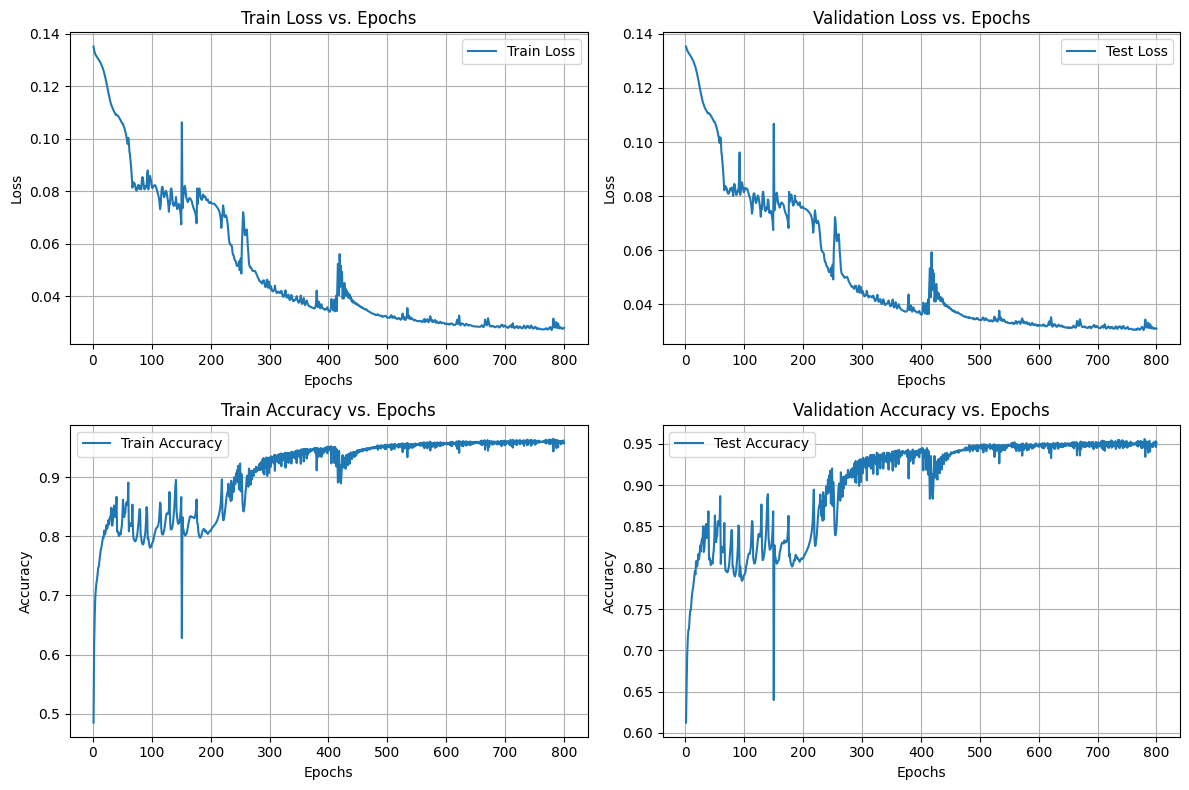

In [174]:
# epochs_range = range(1, epochs + 1)
# last_spoch = epochs 
epochs_range = range(1,801)
last_epoch = 800

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(epochs_range, train_losses[:last_epoch], label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train Loss vs. Epochs')
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(epochs_range, val_losses[:last_epoch], label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Validation Loss vs. Epochs')
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(epochs_range, train_accuracies[:last_epoch], label='Train Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train Accuracy vs. Epochs')
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(epochs_range, val_accuracies[:last_epoch], label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy vs. Epochs')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

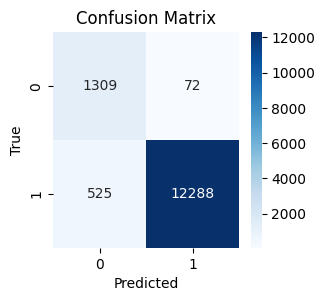

In [45]:
model.eval()
with torch.no_grad():
    outputs_test = model(X_test_tensor)
    predicted_test = (torch.sigmoid(outputs_test)>0.5).float()

# Convert predictions and true labels to numpy arrays
predictions = predicted_test.cpu().numpy()
true_labels = y_test_tensor.cpu().numpy()

labels = ['0','1']
# Compute the confusion matrix
conf_matrix = confusion_matrix(true_labels, predictions)
    
# Plot the confusion matrix
plt.figure(figsize=(3, 2.8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [46]:
predictions.sum()

12360.0

In [47]:
class_report = classification_report(true_labels, predictions)
print(class_report)

              precision    recall  f1-score   support

         0.0       0.71      0.95      0.81      1381
         1.0       0.99      0.96      0.98     12813

    accuracy                           0.96     14194
   macro avg       0.85      0.95      0.90     14194
weighted avg       0.97      0.96      0.96     14194



# Analysis

In [48]:
df_result = pd.DataFrame(np.nan, index=df_target_.index, columns=df_target_.columns)

In [190]:
# # df_result contains the predicted probability of it being a good data (trained for >0.9)

# model = MLP_fcn2().to(device) 
# model.load_state_dict(torch.load('./model_classification/' + model.__class__.__name__+ '_lr-0.001_wd-0.01_0.7.pth'))
# model.eval()
# for day in df_target_.index:
#     for detector in df_target_.columns:

#         typ = df_target_.loc[day,detector]
        
#         if (typ==0 or typ==1 or typ==-1):
#             start = day
#             end = start + pd.Timedelta(days=1) - pd.Timedelta(minutes=2)
#             weekday_number = start.date().weekday()
#             one_hot_day = np.eye(7)[1]

#             triplet_idx = detector_dict[detector][0]
#             det_arr = list(df_triplets.loc[triplet_idx])

#             # Ensure one_hot_day and detector_dict[detector] are numpy arrays
#             one_hot_day = np.array(one_hot_day)
#             detector_data = np.array(detector_dict[detector])

#             # Concatenate one_hot_day and detector_data
#             additional_data = list(np.concatenate([one_hot_day, detector_data]))

#             # Get data for the current day
#             features = []
#             for det in det_arr:
#                 daily_data = list(dfv[start:end][det+'_total_flow'].values)
#                 daily_data.extend(additional_data)
#                 features.append(daily_data)            

#             features = np.array(features)

#             X = [features]  # Add a new axis to make it 2D
#             y = [typ]

#             X = np.array(X, dtype=np.float32) 
#             y = np.array(y, dtype=np.float32) 

#             X_timeseries = X[:, :, :720]
#             X_extra = X[:, :, 720:]
#             X_timeseries_reshaped = X_timeseries.reshape(X.shape[0] * X.shape[1], 720)
#             X_timeseries_scaled = scaler.transform(X_timeseries_reshaped)
#             X_timeseries_scaled = X_timeseries_scaled.reshape(X.shape[0], X.shape[1], 720)
#             X_scaled = np.concatenate((X_timeseries_scaled, X_extra), axis=2)

#             X_tensor = torch.tensor(X_scaled).to(device)
#             y_tensor = torch.tensor(y).to(device)            

#             # Feed into model and calculate accuracy
#             with torch.no_grad():
#                 outputs = model(X_tensor)
#                 predicted_prob = torch.sigmoid(outputs).float()
#                 predicted_prob = predicted_prob.item()

                
#                 df_result.loc[day,detector] = predicted_prob

In [191]:
print(df_result.to_string())

            AID01101  AID01102  AID01103  AID01104  AID01105  AID01106  AID01107  AID01108  AID01109  AID01110  AID01111  AID01112  AID01113  AID01114  AID01115  AID01116  AID01117  AID01118  AID01119  AID01120  AID01121  AID01122  AID01123  AID01124  AID01125  AID01126  AID01127  AID01128  AID01129  AID01130  AID01131  AID01132  AID01133  AID01134  AID01135  AID01136  AID01201  AID01202  AID01203  AID01204  AID01205  AID01206  AID01207  AID01208  AID01209  AID01210  AID01211  AID01212  AID01213  AID01214  AID01215  AID01216  AID01217  AID01218  AID01219  AID01220  AID01221  AID01222  AID01223  AID02104  AID02105  AID02106  AID02107  AID02108  AID02109  AID02110  AID02111  AID02112  AID02113  AID02114  AID02115  AID02116  AID02117  AID02118  AID02119  AID02120  AID02121  AID02122  AID02123  AID02124  AID02125  AID02126  AID02127  AID02201  AID02202  AID02203  AID02204  AID02205  AID02206  AID02207  AID02208  AID02209  AID02210  AID02211  AID02212  AID02213  AID02214  AID02215  AID03102

In [52]:
# # df_result.to_csv('./result_csv/classification_matrix_result.csv')
df_result = pd.read_csv('./result_csv/classification_matrix_result.csv')
df_result.loc[:,'timestamp'] = pd.to_datetime(df_result['timestamp'], errors='coerce')
df_result.set_index("timestamp",inplace=True)

c:\Program Files\Python311\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


In [53]:
df_corr = df_new.drop(columns=drop_list)
df_corr

,AID01101,AID01102,AID01103,AID01104,AID01105,AID01106,AID01107,AID01108,AID01109,AID01110,...,TDSTTR10003,TDSTYR10001,TDSTYR10002,TDSTYR10003,TDSYSR10001,TDSYSR10002,TDSYSR10003,TDSYSR20001,TDSYSR20002,TDSYSR20003
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-10-01,0.898650,0.903773,0.924215,0.949711,0.929371,0.923459,0.948063,0.888193,0.920076,0.951958,...,0.925809,0.479584,0.622537,0.765490,0.704871,0.746989,0.789107,0.784472,0.777367,0.770263
2023-10-02,0.917417,0.918258,0.926319,0.949054,0.923531,0.911870,0.941248,0.893611,0.924538,0.955464,...,0.944220,0.556776,0.605990,0.655204,0.766604,0.791106,0.815608,0.824933,0.780471,0.736009
2023-10-03,0.939282,0.938133,0.944379,0.963134,0.949856,0.938065,0.950912,0.887691,0.914521,0.941350,...,0.958729,0.624389,0.677440,0.730491,0.843846,0.829493,0.815140,0.902003,0.872177,0.842351
2023-10-04,0.946456,0.942767,0.945526,0.964086,0.922714,0.891900,0.914571,0.791977,0.871804,0.951631,...,0.959677,0.618714,0.664850,0.710985,0.835939,0.822803,0.809666,0.908821,0.884080,0.859340
2023-10-05,0.943975,0.943677,0.942314,0.952099,0.919946,0.901238,0.925534,0.842660,0.893094,0.943527,...,0.935905,0.587617,0.634280,0.680943,0.858088,0.839971,0.821853,0.891621,0.870901,0.850181
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-27,0.944450,0.940595,0.944701,0.961098,0.943947,0.943090,0.967822,0.883983,0.920779,0.957574,...,0.947728,0.570550,0.654102,0.737654,0.803489,0.788488,0.773486,0.887871,0.877995,0.868119
2024-03-28,0.939972,0.932141,0.933611,0.956063,0.938642,0.926746,0.945421,0.884165,0.913656,0.943147,...,0.943267,0.584531,0.645559,0.706587,0.818237,0.794057,0.769877,0.885430,0.863804,0.842177
2024-03-29,0.915305,0.917319,0.927474,0.946887,0.918146,0.912283,0.946432,0.905797,0.930976,0.956154,...,0.934039,0.503361,0.605891,0.708422,0.743428,0.738475,0.733522,0.824753,0.786753,0.748754


In [54]:
df_corr_test = df_corr.mask((df_split == 1) | (df_split == 2))      # only value 3 was test data, hence mask 1&2

In [55]:
df_corr_test.isna().sum().sum()

89861

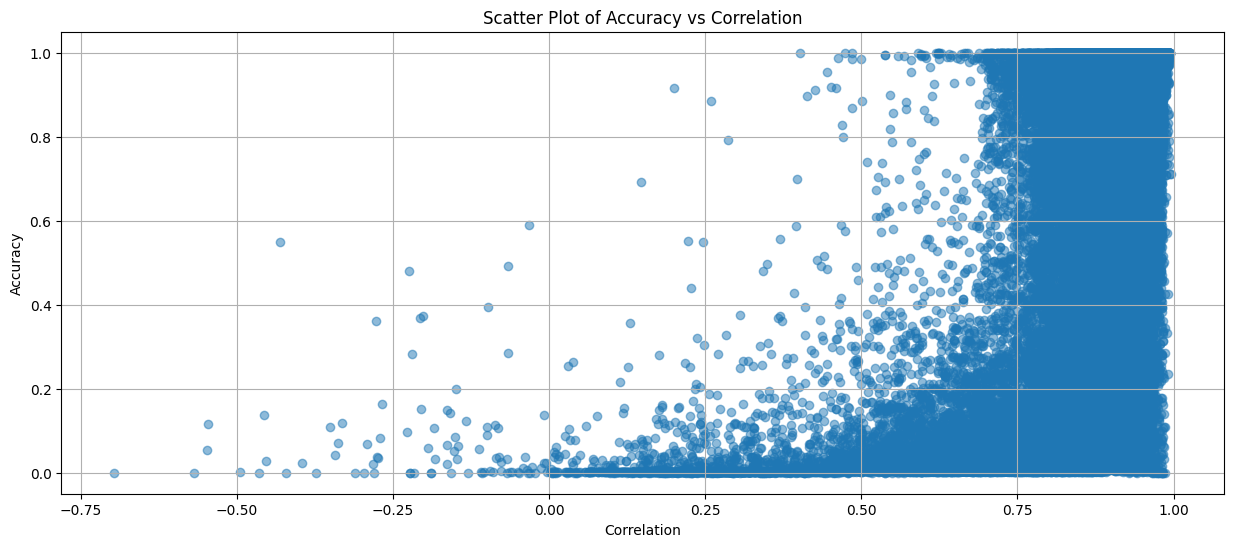

In [56]:
corr_flat = df_corr.values.flatten()
acc_flat = df_result.values.flatten()

# Create scatter plot
plt.figure(figsize=(15, 6))
plt.scatter(corr_flat, acc_flat, alpha=0.5)
plt.xlabel('Correlation')
plt.ylabel('Accuracy')
plt.title('Scatter Plot of Accuracy vs Correlation')
plt.grid(True)
plt.show()

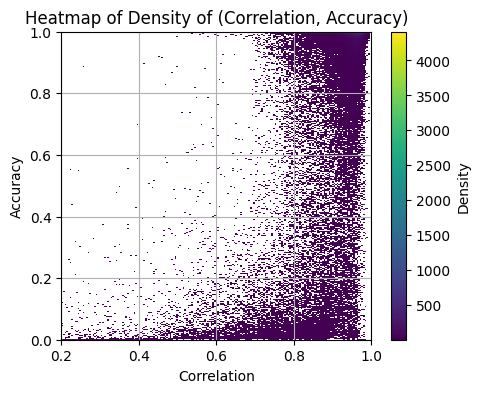

In [59]:
mask = ~np.isnan(corr_flat) & ~np.isnan(acc_flat)
corr_filtered = corr_flat[mask]
acc_filtered = acc_flat[mask]

# Create a 2D histogram (heatmap) of (corr, rank) pairs, ignoring NaN values
plt.figure(figsize=(5, 4))
plt.hist2d(corr_filtered, acc_filtered, bins=400, cmap='viridis', cmin=1)
plt.colorbar(label='Density')
plt.xlabel('Correlation')
plt.ylabel('Accuracy')
plt.xlim(0.2,1)
plt.title('Heatmap of Density of (Correlation, Accuracy)')
plt.grid(True)
plt.show()

[44 45 46 ... 40 38 36]


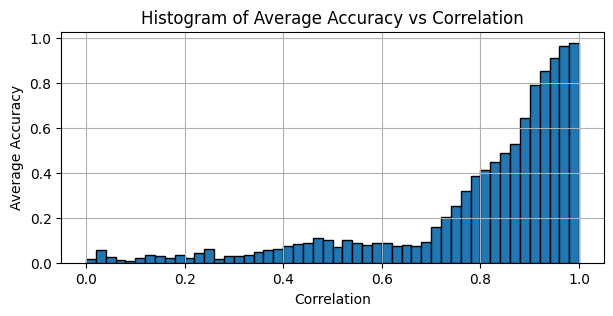

In [58]:
num_bins = 50

# Compute the bin edges and digitize the correlation data
bin_edges = np.linspace(0.0, 1, num_bins + 1)
bin_indices = np.digitize(corr_flat, bin_edges) - 1
print(bin_indices)
# Initialize an array to store the average rank for each bin
average_acc_per_bin = np.zeros(num_bins)

# Compute the average rank for each bin
for i in range(num_bins):
    average_acc_per_bin[i] = np.mean(acc_flat[bin_indices == i])

# Plot the histogram
plt.figure(figsize=(7, 3))
plt.bar(bin_edges[:-1], average_acc_per_bin, width=np.diff(bin_edges), align='edge', edgecolor='k')
plt.xlabel('Correlation')
plt.ylabel('Average Accuracy')
plt.title('Histogram of Average Accuracy vs Correlation')
plt.grid(True)
plt.show()